# MILESTONE 1
---

- Nama : Nur Cahyo Widodo
- Batch : HCK 035 (Pondok Indah)


A. PROBLEM STATEMENT AND DATASET DESCRIPTION


PROBLEM STATEMENT

- Kualitas anggur dipengaruhi oleh berbagai karakteristik kimia seperti tingkat keasaman, pH, kadar alkohol, gula, sulphates, dan faktor kimia lainnya. Namun belum jelas karakteristik mana yang memiliki pengaruh paling kuat terhadap kualitas anggur berdasarkan data.
Tujuan analisis ini adalah mengukur hubungan antara karakteristik kimia anggur dengan kualitas anggur, dan menentukan fitur mana yang paling signifikan dalam membentuk skor kualitas.

SMART
- S -- Specific (Spesifik)
-> Menganalisis berbagai karakteristik kimia anggur (acidity, alcohol, pH, sulphates, dll) untuk melihat sejauh mana masing masing variabel berkontribusi terhadap kualitas anggur, serta mengidentifikasi fitur mana yang paling berpengaruh

- M -- Measurable (Terukur)
-> Pengaruh variabel diukur dengan nilai korelasi antar variabel, feature importance, model prediksi, dan metrik performa 

- A -- Achievable (Dapat dicapai)
-> Mendapatkan data yang akurat untuk mendukung keputusan akhir tentang faktor kimia mana yang paling berpengaruh. Proses nya juga realistis dilakukan dalam waktu yang singkat tanpa membutuhkan sumber daya tambahan yang rumit

- R -- Relevant (Relevan)
-> Produsen anggur dalam meningkatkan kualitas produksi, quality control, penelitian mengenai faktor yang menentukan mutu anggur.

- T -- Time Bound (Berbatas Waktu)
-> Ditargetkan selesai dalam 2 minggu, dengan alur Eksplorasi data, analisis korelasi, preprocessing, pembuatan model, analisis feature importance, dan penyusunan hasil

Penjabaran masalah dengan metode 5W+1h:
- Apakah alkohol menjadi faktor terkuat yang mempengaruhi kualitas anggur ?
- Bagaimana pengaruh tingkat keasaman terhadap kualitas anggur ?
- Apakah pH Anggur yang terlalu tinggi atau terlalu rendah menurunkan kualitas ?
- Bagaimana hubungan sulphates dengan stabilitas dan kualitas akhir anggur ?
- Apakah density dapat menjadi indikator kualitas anggur yang baik ?
- Fitur kimia apa yang secara statistik memiliki hubungan paling kuat dengan kualitas anggur ?

B. DATA LOADING

In [25]:
# Import Tools yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
# Membaca file CSV dataset
df = pd.read_csv("P0M1_Nur_Cahyo_Widodo_dataset.csv")

display(df)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595


In [27]:
# Melihat informasi dasar tentang dataset
# Jumlah baris dan kolom, apakah ada missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [28]:
# Melihat statistik deskriptif dasar seperti Mean, Median, dll
df.describe

<bound method NDFrame.describe of       fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.4             0.700         0.00             1.9      0.076   
1               7.8             0.880         0.00             2.6      0.098   
2               7.8             0.760         0.04             2.3      0.092   
3              11.2             0.280         0.56             1.9      0.075   
4               7.4             0.700         0.00             1.9      0.076   
...             ...               ...          ...             ...        ...   
1138            6.3             0.510         0.13             2.3      0.076   
1139            6.8             0.620         0.08             1.9      0.068   
1140            6.2             0.600         0.08             2.0      0.090   
1141            5.9             0.550         0.10             2.2      0.062   
1142            5.9             0.645         0.12             2.0      0.0

C. DATA CLEANING

In [29]:
# Mengecek apakah ada missing value di setiap kolom
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

Setelah di cek ternyata tidak ada kolom yang kosong dan data sudah clean hingga bisa lanjut ke EDA

D. EXPLORATION AND ANALYSIS

VISUALISASI 1 - Apakah alkohol menjadi faktor terkuat yang mempengaruhi kualitas anggur ?

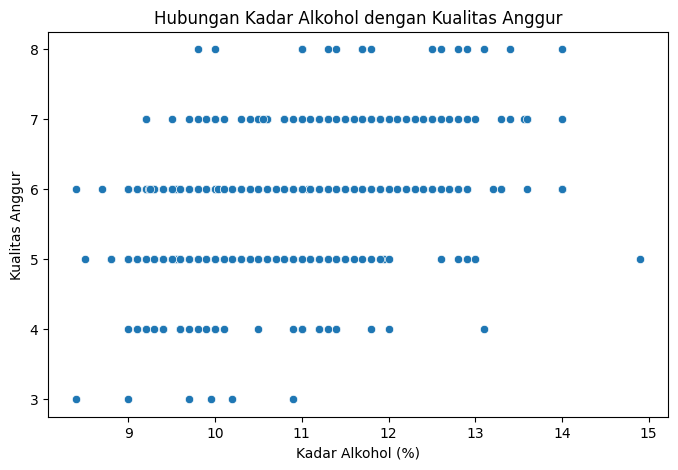

In [30]:
plt.figure(figsize=(8,5)) # Ini adalah untuk mengatur ukuran gambar
sns.scatterplot(data=df, x='alcohol', y='quality') # Scatter Plot antara alcohol dan quality
plt.title("Hubungan Kadar Alkohol dengan Kualitas Anggur") # Judul Grafik
plt.xlabel("Kadar Alkohol (%)") # Label sumbu x
plt.ylabel("Kualitas Anggur") # Label sumbu y
plt.show() # Menampilkan tabel nya

Berdasarkan dari tabel diatas 
Kualitas tidak selalu berarti kadar alkohol tinggi; wine yang kompleks, seimbang, dan aromatik (meski kadar alkoholnya standar 12-14%) dianggap berkualitas tinggi oleh penikmatnya  Kadar alkohol yang terlalu tinggi bisa membuat wine terasa "panas"

VISUALISASI 2 - Bagaimana pengaruh tingkat keasaman terhadap kualitas anggur ?

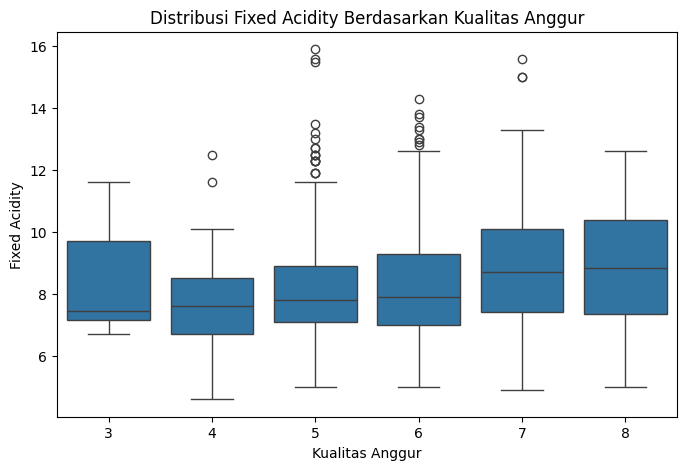

In [31]:
plt.figure(figsize=(8,5)) # Mengatur ukuran grafik
sns.boxplot(data=df, x='quality', y='fixed acidity') # Membuat boxplot fixed activity berdasarkan nilai quality
plt.title("Distribusi Fixed Acidity Berdasarkan Kualitas Anggur")
plt.xlabel("Kualitas Anggur") # Label sumbu x
plt.ylabel("Fixed Acidity") # Label sumbu y
plt.show()


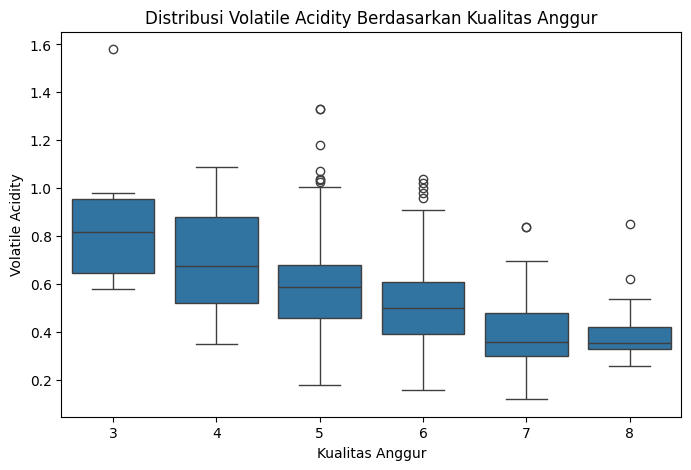

In [32]:
plt.figure(figsize=(8,5)) # Mengatur ukuran grafik
sns.boxplot(data=df, x='quality', y='volatile acidity') # Membuat boxplot fixed activity berdasarkan nilai quality
plt.title("Distribusi Volatile Acidity Berdasarkan Kualitas Anggur")
plt.xlabel("Kualitas Anggur") # Label sumbu x
plt.ylabel("Volatile Acidity") # Label sumbu y
plt.show()

Penjelasan dari tabel berikut:
Kenapa saya mengambil fixed acidity dan volatile acidity sebagai visualisasi untuk menjawab pertanyaan no. 2 (Bagaimana pengaruh tingkat keasaman terhadap kualitas anggur)

Karena tingkat keasaman dalam anggur diwakili oleh 2 jenis acidity yang berbeda :
1. Fixed acidity (asam yang tidak menguap) yang sifatnya stabil, tidak menguap ketika dipanaskan, memberi rasa asam dasar pada anggur

2. Volatile acidity (asam yang mudah menguap) yang sifatnya menguap ketika dipanaskan, beraroma tajam, jika terlalu tinggi wine terasa seperti cuka.

Fitur fixed acidity dan volatile acidity dipilih karena keduanya komponen utama yang mewakili tingkat keasaman anggur. Fixed acidity menggambarkan kesaman stabil yang mempengaruhi struktur rasa, sedangkan volatile acidity mewakili keasaman yang mudah menguap dan dapat menurunkan kualitas wine apabila kadarnya terlalu tinggi. Oleh karena itu analisis keduanya fitur ini penting untuk memahami hubungan antara keasaman dan kualitas anggur.

VISUALISASI 3 - Apakah pH Anggur yang terlalu tinggi atau terlalu rendah menurunkan kualitas ?

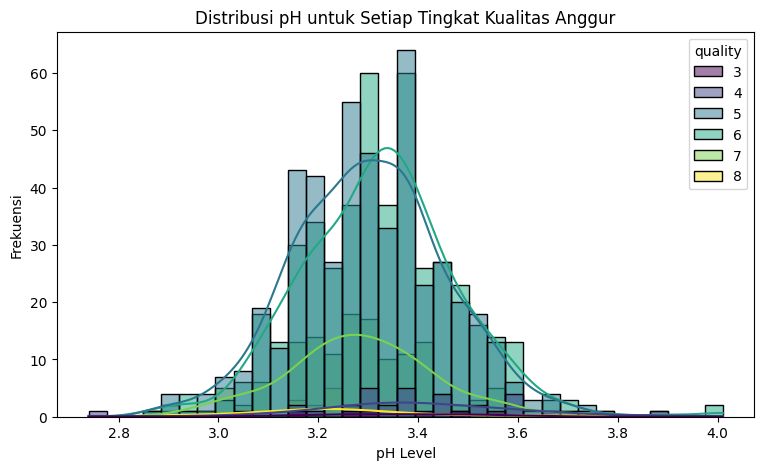

In [33]:
plt.figure(figsize=(9,5)) # Mengatur ukuran grafik
sns.histplot(data=df, x='pH', hue='quality', # Kolom pH yang ingin dianalisis dan warna berdasarkan kualitas anggur
             kde=True,                  # Menampilkan kurva KDE untuk melihat pola distribusi
             palette='viridis',         # Warna agar grafik lebihh muda dibaca
             alpha=0.5              # Transparansi untuk menghindari warna bertumpuk
)

plt.title("Distribusi pH untuk Setiap Tingkat Kualitas Anggur") # Judul grafik
plt.xlabel("pH Level")      # Label sumbu x
plt.ylabel("Frekuensi")     # Label sumbu y
plt.show() # Menampilkan grafik

Berdasarkan grafik diatas

1. Mayoritas nilai pH berkumpul pada rentang 3.1 - 3.4 
Ini menunjukan bahwa wine pada dataset memiliki tingkat keasaman yang relatif stabil, tidak terlalu extreme rendah atau tinggi
2. Wine kualitas tinggi (6-7) cenderung memiliki pH sedikit lebih rendah
pH yang sedikit lebih rendah -> wine lebih asam -> itu lebih fresh dan disukai

pH tinggi (3.6 - 4.0) -> frekuensi nya sedikit -> kualitas nya rendah  
pH optimal (3.1 - 3.3) -> frekuensi nya besar -> banyak yang berkualitas baik  
pH rendah (<3.0) -> frekuensi sangat sedikit -> pengaruh nya tidak signifikan  

VISUALISASI 4 - Bagaimana hubungan sulphates dengan stabilitas dan kualitas akhir anggur ?

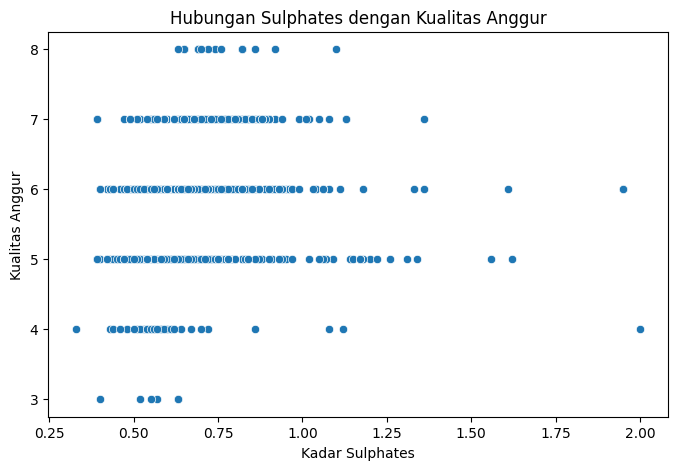

In [34]:
plt.figure(figsize=(8,5)) # Mengatur ukuran grafik
sns.scatterplot(data=df, x='sulphates', y='quality') # Variabel sulphates sebagai sumbu x dan Variabel quality sebagai sumbu y

plt.title("Hubungan Sulphates dengan Kualitas Anggur") # Judul Grafik
plt.xlabel("Kadar Sulphates") # Label sumbu x
plt.ylabel("Kualitas Anggur") # Label sumbu y
plt.show() # Menampilkan grafik

Sulphates berfungsi sebagai bahan pengawet alami pada wine, dan jumlahnya bisa mempengaruhi stabilitas serta rasa wine. Untuk melihat hubungan keduanya, scatterplot adalah visualisasi terbaik karena :
sulphates = variabel numerik
quality = variabel numerik kategorikal 
Scatterplot menunjukan arah hubungan

Berdasarkan grafik diatas 
1. Wine kualitas tinggi cenderung memiliki kadar sulphates lebih tinggi
Saat melihat titik titik di grafik:  
Titik dengan kualitas 7-8 muncul lebih banyak di area Sulphates 
Ini menunjukan kecenderungan positif, semakin tinggi kadar sulphates semakin besar peluang kualitas wine lebih baik

2. Wine kualitas rendah banyak muncul pada sulphates rendah
Saat melihat titik titik di grafik:
Di area sulphates 0.2-0.4 titik kualitas nya paling sering adalah 3-5 artinya wine dengan sulphates rendah cenderung memliki kualitas rendah juga

Visualisasi Scatterplot menunjukan bahwa wine dengan kadar Sulphates yang lebih tinggi cenderung memiliki kualitas yang lebih baik. Wine berkualitas rendah lebih banyak ditemukan pada kadar sulphates rendah juga. Sedangkan wine berkualitas tinggi sering muncul pada kadar sulphates menengah hingga tinggi. Hal ini mengidentikasikan bahwa sulphates memiliki pengaruh positif terhadap kualitas anggur karena berperan sebagai pengawet alami.

STATISTIK DESKRIPTIF - Apakah density dapat menjadi indikator kualitas anggur yang baik ?

Untuk menjawab nya, saya memakai :
- Central Tendency -> mean,median
- Measure of variance -> std(standar deviasi), variance
- Outlier Analysis -> IQR
- Per quality -> supaya terlihat apakah density berubah signifikan antar kualitas

In [35]:
# Statistik Deskriptif untuk density per kualitas
density_stats = df.groupby('quality')['density'].agg(['mean', 'median', 'var', 'std']) # Menghitung central tendency dan measure of variance untuk density berdasarkan quality

density_stats

,mean,median,var,std
quality,,,,
3,0.997682,0.997565,0.000005,0.002218
4,0.996669,0.996640,0.000003,0.001734
5,0.997073,0.996920,0.000003,0.001637
6,0.996610,0.996520,0.000004,0.002002
7,0.996071,0.995680,0.000005,0.002292
8,0.995553,0.995580,0.000005,0.002217


- Perilaku Rata - Rata (Mean) Density per Quality
1. Wine kualitas rendah (3) memiliki mean density 0.997682
Ini density paling tinggi dari semua kelompok
2. Wine kualitas tinggi (7-8) memiliki mean density lebih rendah, yaitu:  
Quality 7 = 0.996071  
Quality 8 = 0.995553  

Semakin tinggi kualitas anggur mean density nya semakin rendah

- Nilai Median mendukung pola Mean
Median juga turun dari :  
Quality 3 = 0.997565 menjadi Quality 8 = 0.995580

Ini konsisten density sedikit lebih rendah pada kualitas tinggi

- Variance (Var) dan Standard Deviation (std) sangat kecil
Melihat kolom var dan std:  
1. Variance disemua kualitas = 0.000003 - 0.000005
2. Std di semua kualitas = 0.0016 - 0.0022

Density hampir tidak bervariasi antar wine, karena variasi terlalu kecil tidak mungkin density menjadi indikator kualitas yang kuat

Jadi, dengan mean, median, var, dan std dapat disimpulkan bahwa density tidak dapat menjadi indikator kualitas anggur yang baik, karena perbedaan antar kualitas terlalu kecil dan tidak memberikan pola yang kuat untuk membedakan kualitas wine

Outlier Analysis khusus Density

In [36]:
Q1 = df['density'].quantile(0.25)
Q3 = df['density'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_density = df[(df['density'] < lower_bound) | (df['density'] > upper_bound)]
len(outlier_density)


36

Penjelasan Outlier Density berdasarkan perhitungan IQR ditemukan sebanyak 36 sampel yang termasuk kategori outlier pada fitur density. Jumlah ini sangat kecil bila dibandingkan dengan total dataset, sehingga dapat disimpulkan bahwa nilai density pada sebagian besar wine berada dalam rentang yang stabil dan tidak terlalu bervariasi.

Oulier yang muncul juga tidak terkonsentrasi pada satu kategori kualitas tertentu, melainkan tersebar secara acak. Hal ini menunjukan bahwa nilai density extreme tidak memiliki keterkaitan khusus dengan kualitas anggur tertentu.

STATISTIK INFERENSIAL - Fitur kimia apa yang secara statistik memiliki hubungan paling kuat dengan kualitas anggur ?

Untuk Menjawab nya saya menggunakan:  
Analisis statistik inferensial dilakukan menggunakan uji korelasi Pearson dan Spearman untuk mengukur hubungan antara fitur kimia dengan kualitas wine, disertai pengujian signifikasi menggunakan p-value sebagai dasar pengambilan keputusan hipotesis

In [45]:
# STATISTIK INFERENSIAL:
# Menguji hubungan fitur kimia terhadap kualitas wine menggunakan Pearson & Spearman
# Untuk Menentukan fitur mana yang paling kuat dan signifikan

import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr

# Pilih semua kolom numerik kecuali quality
features = [c for c in df.select_dtypes(include=[np.number]).columns if c != 'quality']

hasil = []

for f in features:
    x = df[f]
    y = df['quality']

    pear_r, pear_p = pearsonr(x, y) # Pearson correlation + p-value
    spear_r, spear_p = spearmanr(x, y) # Spearman correlation + p-value

    hasil.append([f, pear_r, pear_p, spear_r, spear_p])

# Masukan ke dataframe
inferensi_df = pd.DataFrame(hasil, columns=['feature', 'pearson_r', 'pearson_p', 'spearman_r', 'spearman_p'])

# Urutan fitur berdasarkan kekuatan hubungan
inferensi_df['abs_pearson'] = inferensi_df['pearson_r'].abs()
inferensi_df = inferensi_df.sort_values('abs_pearson', ascending=False)

# Format angka nya biar rapih
def format_p(p):
    return "<0.001" if p < 0.0001 else f"{p:.3f}"

def format_r(r):
    return f"{r:.3f}"

df_rapih = pd.DataFrame({
    "feature": inferensi_df["feature"],
    "pearson_r": inferensi_df["pearson_r"].apply(format_r),
    "pearson_p": inferensi_df["pearson_p"].apply(format_p),
    "spearman_r": inferensi_df["spearman_r"].apply(format_r),
    "spearman_p": inferensi_df["spearman_p"].apply(format_p)
})

df_rapih.index = range(1, len(df_rapih) + 1)

display(df_rapih)

,feature,pearson_r,pearson_p,spearman_r,spearman_p
1,alcohol,0.485,<0.001,0.495,<0.001
2,volatile acidity,-0.407,<0.001,-0.398,<0.001
3,sulphates,0.258,<0.001,0.394,<0.001
4,citric acid,0.241,<0.001,0.223,<0.001
5,total sulfur dioxide,-0.183,<0.001,-0.195,<0.001
6,density,-0.175,<0.001,-0.177,<0.001
7,chlorides,-0.124,<0.001,-0.194,<0.001
8,fixed acidity,0.122,<0.001,0.104,0.000
9,Id,0.070,0.018,0.084,0.004
10,free sulfur dioxide,-0.063,0.032,-0.059,0.045


Dari tabel berikut berdasarkan uji statistik pearson dan spearman, fitur kimia yang memiliki hubungan paling kuat dengan kualitas anggur adalah alcohol (r=0.485, p<0.001). Artinya peningkatan kadar alkohol secara konsisten diikuti peningkatan kualitas wine. Fitur berikutnya yang juga berpengaruh kuat adalah Volatile Acidtiy (r=-0.407, p<0.001), namun dengan arah hubungan negatif sehingga semakin tinggi Volatile Acidity makan kualitas wine menurun. Fitur signifikan lainnya adalah sulphates dan citric acid, meskipun kekuatannya lebih moderat.

Dengan demikian fitur kimi yang secara statistik paling berpengaruh terhadap kualitas wine adalah alkohol, menjadikan nya indikator terbaik dibandingkan dengan fitur kimia lainnya.

E. CONCLUSION

Final Conclusion - Kesimpulan Akhir Analisi Wine Quality Dataset

1. Tidak ditemukan missing value dan data dapat digunakan tanpa proses imputasi
Setelah melakukan pengecekan pada tahap awal seluruh kolom pada dataset ini memiliki data lengkap sehingga bisa langsung dianalisis.

2. Visualisasi menunjukan pola awal hubungan antara fitur kimia dan kualitas wine
- Alhocol vs Quality  
Scatter plot menunjukan tren yang cukup jelas bahwa wine dengan kadar alkohol lebih tinggi cenderung memiliki kualitas yang lebih tinggi.

- Acidity (fixed & volatile acidity) vs quality
Plot boxplot menunjukan bahwa volatile acidity yang tinggi menurunkan kualitas wine.
fixed acidity tidak memiliki pola kuat. cenderung stabil diberbagai level kualitas.

- pH vs Quality
Distribusi pH sebagian besar berada di rentang (3.1 – 3.4) dan tidak menunjukkan pola kuat terhadap kualitas. Wine kualitas tinggi juga berada di rentang pH yang sama.

- Sulphates vs Quality
Sulphates memiliki hubungan moderat: kualitas lebih tinggi cenderung muncul pada nilai sulphates yang sedikit lebih tinggi.

3. Statistik Deskriptif: Density bukan indikator kuat kualitas wine.
Berdasarkan perhitungan mean, median, variance, dan standar deviasi per kategori kualitas, terlihat bahwa:
- Density antar-kategori kualitas hampir sama, variansinya kecil.
- IQR menunjukkan penyebaran density antar wine relatif sempit dan stabil.
- Tidak ada outlier ekstrem pada density yang mempengaruhi kualitas secara signifikan.
Kesimpulan:
Density bukan indikator yang baik untuk menilai kualitas wine.

4. Statistik Inferensial: Alcohol adalah fitur kimia paling berpengaruh terhadap kualitas.
Dengan menggunakan korelasi Pearson dan Spearman, dilakukan pengujian signifikansi (p-value) untuk menentukan fitur mana yang memiliki hubungan paling kuat.
        Hasil utama:  
    Rank                 Fitur                                    Hubungan  
    1	                 Alcohol                Hubungan positif terkuat Signifikan (<0.001)  
    2                    Volatile Acidity       Hubungan negatif kuat, signifikan  
    3                    Sulphates              Hubungan positif moderat, signifikan  
    4                    Citric Acid            Hubungan positif lemah-moderat  
    5                    Total Sulfur Dioxide   Negatif lemah  
